# Statistical Testing:- Telco Customer Churn

This notebook uses statistical hypothesis testing to determine whether selected customer characteristics are significantly associated with customer churn.

The analysis focuses on comparing numerical variables between churned and retained customers and examining the relationship between categorical variables and churn.

The following statistical tests are used:

- **Welch's t-test** to compare the mean values of numerical variables between churned and retained customers
- **Chi-square test of independence** to examine whether categorical variables are significantly associated with customer churn

The following variables are analyzed:

- Tenure
- Monthly Charges
- Gender
- Partner status
- Dependents

A significance level of **α = 0.05** is used throughout the analysis.

The objective is to determine which customer characteristics show statistically significant relationships with churn and support the findings from the exploratory analysis.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from pathlib import Path

load_dotenv()

file_path = Path("..") / "Data" / "Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Statistical Testing Approach

Statistical hypothesis testing is used to determine whether the observed differences and relationships in the dataset are likely to be statistically significant rather than occurring by chance.

### Significance Level

A significance level of **5% (α = 0.05)** is used for all statistical tests.

- If the **p-value is less than 0.05**, the null hypothesis is rejected.
- If the **p-value is greater than or equal to 0.05**, there is insufficient evidence to reject the null hypothesis.

## 1. Tenure and Customer Churn

### Welch's T-Test

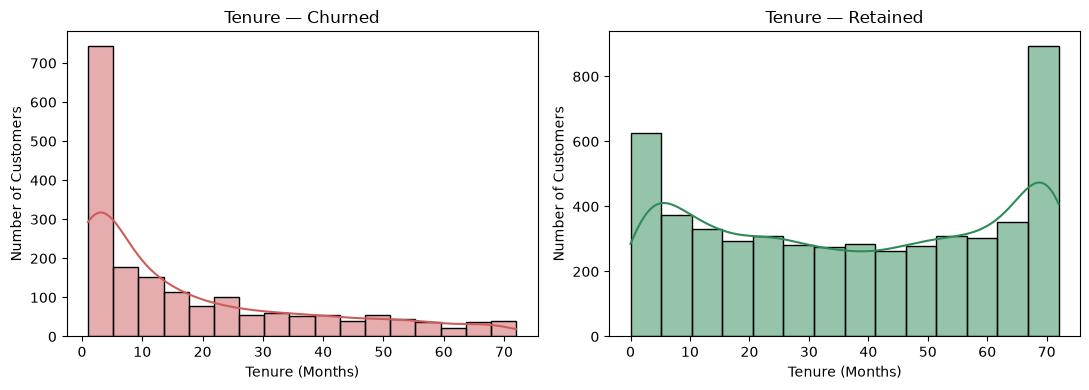

t-statistic: -34.824
p-value:     1.195494547260576e-232
=> Reject H0: mean tenure differs significantly between churned and retained customers.


In [2]:
churned = df.loc[df['Churn'] == 'Yes', 'tenure']
retained = df.loc[df['Churn'] == 'No', 'tenure']

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(churned, kde=True, ax=ax[0], color='indianred')
ax[0].set_title('Tenure — Churned')
ax[0].set_xlabel("Tenure (Months)")
ax[0].set_ylabel("Number of Customers")
sns.histplot(retained, kde=True, ax=ax[1], color='seagreen')
ax[1].set_title('Tenure — Retained')
ax[1].set_xlabel("Tenure (Months)")
ax[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

t_stat, p_value = stats.ttest_ind(churned, retained, equal_var=False)  # Welch's t-test: doesn't assume equal variance

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value}")

if p_value < 0.05:
    print("=> Reject H0: mean tenure differs significantly between churned and retained customers.")
else:
    print("=> Fail to reject H0: no significant difference in mean tenure.")

**Conclusion:**  
- The Welch's t-test produced a p-value of approximately **1.20 × 10⁻²³²**, which is far below the significance level of 0.05.
- Therefore, the null hypothesis is rejected. There is a statistically significant difference in average tenure between churned and retained customers.
- The negative t-statistic indicates that churned customers generally have a lower average tenure than retained customers. This suggests that customers are more likely to churn earlier in their relationship with the company.


## 2. Monthly Charges and Customer Churn

### Welch's T-Test

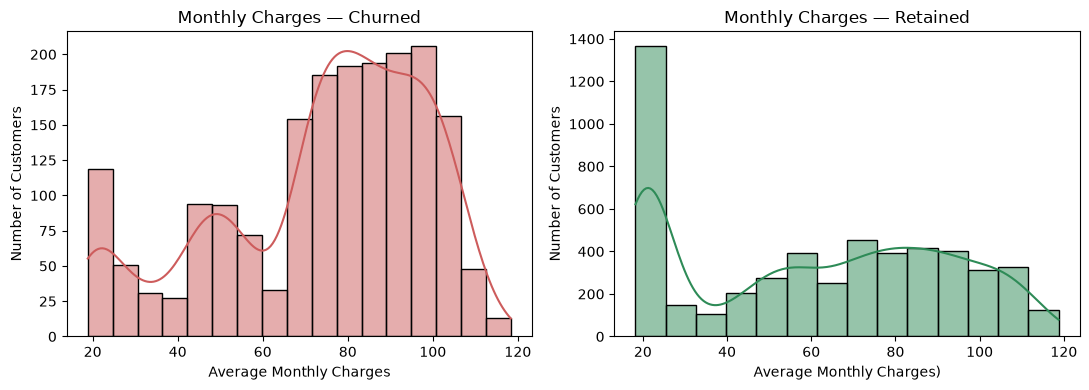

t-statistic: 18.408
p-value:     8.592449331547067e-73
=> Reject H0: mean Monthly revenue differs significantly between churned and retained customers.


In [3]:
churned = df.loc[df['Churn'] == 'Yes', 'MonthlyCharges']
retained = df.loc[df['Churn'] == 'No', 'MonthlyCharges']

ig, ax = plt.subplots(1, 2, figsize=(11, 4))

sns.histplot(churned, kde=True, ax=ax[0], color='indianred')
ax[0].set_title('Monthly Charges — Churned')
ax[0].set_xlabel("Average Monthly Charges")
ax[0].set_ylabel("Number of Customers")

sns.histplot(retained, kde=True, ax=ax[1], color='seagreen')
ax[1].set_title('Monthly Charges — Retained')
ax[1].set_xlabel("Average Monthly Charges)")
ax[1].set_ylabel("Number of Customers")

plt.tight_layout()
plt.show()

t_stat, p_value = stats.ttest_ind(churned, retained, equal_var=False)

alpha = 0.05

print(f"t-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value}")

if p_value < 0.05:
    print("=> Reject H0: mean Monthly revenue differs significantly between churned and retained customers.")
else:
    print("=> Fail to reject H0: no significant difference in mean Monthly revenue.")

**Conclusion:**
- The Welch's t-test produced a p-value of approximately **8.59 × 10⁻⁷³**, which is also far below the significance level of 0.05.
- Therefore, the null hypothesis is rejected. The average monthly charges of churned and retained customers are significantly different.
- The positive t-statistic indicates that churned customers generally have higher monthly charges. This suggests that higher monthly costs may be associated with an increased risk of churn.


## 3. Gender and Customer Churn

### Chi-Square Test of Independence

In [4]:
contingency = pd.crosstab(df['gender'], df['Churn'])
display(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nChi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print("\n=> Reject H0: Gender IS significantly associated with contract type.")
else:
    print("\n=> Fail to reject H0: no significant association found.")

Churn,No,Yes
gender,,
Female,2549,939
Male,2625,930



Chi-square statistic: 0.484
Degrees of freedom:   1
p-value:              0.486579

=> Fail to reject H0: no significant association found.


**Conclusion:**
- The Chi-square test produced a p-value of **0.4866**, which is greater than the significance level of 0.05.
- Therefore, there is insufficient evidence to conclude that gender is significantly associated with customer churn.
- The churn patterns for male and female customers are statistically similar in this dataset. Gender does not appear to be a meaningful factor for identifying customers at risk of churn.


## 4. Partner Status and Customer Churn

### Chi-Square Test of Independence

In [6]:
contingency = pd.crosstab(df['Partner'], df['Churn'])
display(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nChi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value}")

alpha = 0.05
if p_value < alpha:
    print("\n=> Reject H0: Having a partner IS significantly associated with contract type.")
else:
    print("\n=> Fail to reject H0: no significant association found.")

Churn,No,Yes
Partner,,
No,2441,1200
Yes,2733,669



Chi-square statistic: 158.733
Degrees of freedom:   1
p-value:              2.1399113440759935e-36

=> Reject H0: Having a partner IS significantly associated with contract type.


**Conclusion:**
- The Chi-square test produced a p-value of approximately **2.14 × 10⁻³⁶**, which is far below the significance level of 0.05.
- Therefore, the null hypothesis is rejected. Partner status is significantly associated with customer churn.
- Customers without a partner show a higher churn rate than customers with a partner, suggesting that customers with partners are more likely to remain with the company.

## 5. Dependents and Customer Churn

### Chi-Square Test of Independence

In [7]:
contingency = pd.crosstab(df['Dependents'], df['Churn'])
display(contingency)

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\nChi-square statistic: {chi2:.3f}")
print(f"Degrees of freedom:   {dof}")
print(f"p-value:              {p_value}")

alpha = 0.05
if p_value < alpha:
    print("\n=> Reject H0: Having Dependents IS significantly associated with contract type.")
else:
    print("\n=> Fail to reject H0: no significant association found.")

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1784,326



Chi-square statistic: 189.129
Degrees of freedom:   1
p-value:              4.9249216612154196e-43

=> Reject H0: Having Dependents IS significantly associated with contract type.


**Conclusion:**
- The Chi-square test produced a p-value of approximately **4.92 × 10⁻⁴³**, which is far below the significance level of 0.05.

- Therefore, the null hypothesis is rejected. Having dependents is significantly associated with customer churn.

- Customers without dependents have a substantially higher churn rate than customers with dependents, indicating that customers with dependents are more likely to remain with the company.

## Overall Conclusion

The statistical analysis provides evidence that **tenure, monthly charges, partner status, and dependent status are significantly associated with customer churn**.

Among the variables tested, **gender was not found to have a statistically significant relationship with churn**.

Overall, customers with shorter tenure, higher monthly charges, no partner, and no dependents appear to have a higher risk of churn. These findings can help identify customer segments that should be prioritized for retention strategies.